# BAMBOO charges, energy decomposition, and deployment

A quick tour of what BAMBOO predicts beyond the energy: **per-atom partial
charges** (conserved to the total charge), the **energy split** into the
semi-local NN term and the charge-equilibrium electrostatic term, the molecular
**dipole**, and how to run it as an ASE calculator. No training; this is about
the model's outputs and symmetries.

## 0. Build a BAMBOO

In [1]:
import logging, warnings
logging.disable(logging.WARNING); warnings.filterwarnings("ignore")
import numpy as np, torch
torch.set_default_dtype(torch.float64)
import xnns
from xnns.common.config import from_dict
from xnns.common.data import structure_to_graph
from xnns.common.models import build_model, ForceStressOutput

cfg = from_dict({"model": {"name": "bamboo", "cutoff": 5.0, "n_features": 64,
    "n_rbf": 32, "n_interactions": 3, "extra": {"num_heads": 16}}})
model = build_model(cfg.model)
print(model.__class__.__name__, "|", sum(p.numel() for p in model.parameters()),
      "params |", model.node_feature_dim, "invariant features")

BAMBOO | 103620 params | 64 invariant features


## 1. Outputs on a small molecule

A single water-like cluster. BAMBOO returns the per-structure energy, its
`energy_nn` / `energy_elec` components, per-atom `charges`, the `dipole`, and
the invariant `node_features` (consumed e.g. by the LES wrapper).

In [2]:
rng = np.random.default_rng(0)
s = {"pos": rng.uniform(0, 3, (6, 3)), "atomic_numbers": [8, 1, 1, 6, 7, 9]}
g = structure_to_graph(s, 5.0)
out = model(g)
for k, v in out.items():
    print(f"{k:14s} shape {tuple(v.shape)}")
print("\nenergy == energy_nn + energy_elec :",
      torch.allclose(out["energy"], out["energy_nn"] + out["energy_elec"]))
print("energy == sum(node_energy)        :",
      torch.allclose(out["energy"], out["node_energy"].sum()))

node_energy    shape (6,)
energy         shape (1,)
node_features  shape (6, 64)
charges        shape (6,)
dipole         shape (1, 3)
energy_nn      shape (1,)
energy_elec    shape (1,)

energy == energy_nn + energy_elec : True
energy == sum(node_energy)        : True


## 2. Charge conservation: neutral and charged

BAMBOO squashes the raw charge to `[-charge_ub, charge_ub]` and then shifts every
atom so the total exactly matches the requested charge (0 by default, or a
`total_charge` attribute on the graph).

In [3]:
print("neutral total charge:", float(model(g)["charges"].sum()))
g.total_charge = torch.tensor([-1.0])   # e.g. an anionic cluster
print("anion total charge  :", float(model(g)["charges"].sum()))

neutral total charge: -5.204170427930421e-18
anion total charge  : -1.0


## 3. Symmetries: energy invariant, forces equivariant, dipole invariant in magnitude

In [4]:
fs = ForceStressOutput(model)
R, _ = np.linalg.qr(rng.standard_normal((3, 3)))
if np.linalg.det(R) < 0: R[:, 0] *= -1
o1 = fs(structure_to_graph(s, 5.0))
s2 = {"pos": s["pos"] @ R.T + 4.0, "atomic_numbers": s["atomic_numbers"]}
o2 = fs(structure_to_graph(s2, 5.0))
print("dE (rot+trans)       :", float((o1["energy"] - o2["energy"]).abs().max()))
print("dF (rotate forces)   :", float(np.abs(o1["forces"].detach().numpy() @ R.T
                                             - o2["forces"].detach().numpy()).max()))
print("d|dipole|            :", float((o1["dipole"].norm() - o2["dipole"].norm()).abs()))

dE (rot+trans)       : 4.440892098500626e-16
dF (rotate forces)   : 8.326672684688674e-17
d|dipole|            : 4.440892098500626e-16


## 4. The electrostatic term is long-range

Unlike the 5 Å semi-local GET, `energy_elec` sums a damped Coulomb over **all**
pairs. We slide two fluoride-like atoms apart (freezing the predicted charges)
and watch the electrostatic energy follow the expected ``~ q_i q_j / r`` tail
well beyond the cutoff.

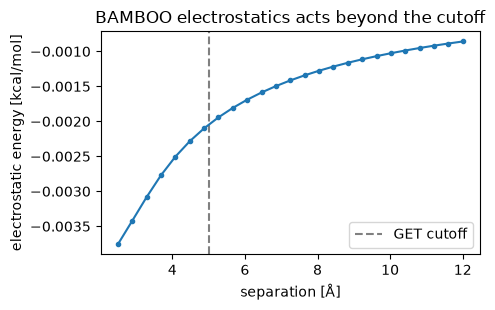

In [5]:
m = model
seps = np.linspace(2.5, 12.0, 25)
e_elec = []
for d in seps:
    pair = {"pos": np.array([[0, 0, 0], [d, 0, 0]]), "atomic_numbers": [9, 3]}  # F, Li
    gp = structure_to_graph(pair, 5.0)
    e_elec.append(float(m(gp)["energy_elec"][0]))
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3.2))
plt.axvline(5.0, ls="--", c="gray", label="GET cutoff")
plt.plot(seps, e_elec, "o-", ms=3)
plt.xlabel("separation [Å]"); plt.ylabel("electrostatic energy [kcal/mol]")
plt.title("BAMBOO electrostatics acts beyond the cutoff"); plt.legend()
plt.tight_layout(); plt.savefig("bamboo_electrostatic_tail.png", dpi=110); plt.show()

## 5. Deploy as an ASE calculator

`XNNSCalculator` wraps any xnns model for ASE (energies, forces, and, for
periodic cells, stress). BAMBOO works in kcal/mol and Å.

In [6]:
from ase import Atoms
from xnns.common.deploy import XNNSCalculator

atoms = Atoms("OH2", positions=[[0, 0, 0], [0.96, 0, 0], [-0.24, 0.93, 0]])
atoms.calc = XNNSCalculator(ForceStressOutput(model), cutoff=5.0)
print("energy [kcal/mol]:", round(atoms.get_potential_energy(), 4))
print("forces shape     :", atoms.get_forces().shape)

energy [kcal/mol]: -0.7525
forces shape     : (3, 3)


## Summary

BAMBOO is a single model that predicts a physically-decomposed energy
(`energy_nn` + `energy_elec`), conserved per-atom partial charges, and the
molecular dipole, with correct E(3) symmetries and a genuinely long-range
electrostatic term, all through the standard xnns `AtomicGraph` /
`ForceStressOutput` / `XNNSCalculator` interfaces.